<div style='font-size: 30px; color: #000000;background-color: #9BEBA5;border: 3px solid black;text-align: center;'>
<div><b>Inductive learning scheme <br> for indoor positioning systems </b></div>
</div>

### Table of contents
0. [Environment setup](#environment-setup)
1. [Data preprocessing and graph construction](#graph-construction)
2. [Optimization](#optimization)
3. [Training & Testing](#training_testing)

___

# 0. Environment setup

## Module loading

In [1]:
import os
import sys
import time
import glob
import json
import ast
import re
import importlib
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import itertools 
from itertools import product
import optuna
import torch

sys.path.append(os.path.abspath('../src'))

# Custom libraries
import indoorloc_enums
indoorloc_enums = importlib.reload(indoorloc_enums)
import indoorloc_data
indoorloc_data = importlib.reload(indoorloc_data)
import indoorloc_models
indoorloc_models = importlib.reload(indoorloc_models)
import indoorloc_viz
indoorloc_viz = importlib.reload(indoorloc_viz)

import indoorloc_data as ildata
from indoorloc_data import (
    IndoorLocDataset, 
    IndoorLocGraphDataLoader, 
    IndoorLocPreprocessor, 
    IndoorLocGraphData
)
import indoorloc_viz as ilviz
from indoorloc_models import (
    SAGERegressor,
)
import indoorloc_trainer as iltrainer
from indoorloc_trainer import (
    GNNRegressionTrainer
)

/home/astrid/GITHUB/github-venv/lib/python3.12/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._show_config()


## Environment information

System characteristics and CUDA availability check.

In [85]:
ilviz.EnvironmentInfo().show()


##################################################
	ENVIRONMENT INFORMATION
##################################################

Operating System: Linux
CPU: AMD Ryzen 5 2600 Six-Core Processor
RAM: 15.56 GB
--------------------------------------------------
Selected device cuda
CUDA version: 12.6
Number of available GPUs: 1
GPU 0: NVIDIA GeForce RTX 2060
--------------------------------------------------


----

# 1. Data preprocessing and graph construction

Data preprocessing and graph construction for each dataset from the grid’s parameter combinations.

Available datasets:
* **UJIIndoorLoc**: 'UJI1',
* **UTSIndoorLoc**: 'UTS1',
* **SODIndoorLoc**: 'SOD01', 'SOD02', 'SOD06',
* **TUTDatasets**: 'SAH1', 'TIE1', 'TUT1', 'TUT2', 'TUT3', 'TUT4', 'TUT5'

Available parameters:
* `normalization`: 'lineal', 'powed'
* `pca_components`: Between 0.0 and 1.0
* `distance_metric`: 'manhattan', 'cosine'
* `n_neighbors`: At least 1 is required
* `graph_scheme`: 'transductive', 'inductive'

In [216]:
# Select dataset(s)
dataset_selection = ['TIE1']
datasets = {name: name for name in dataset_selection}

# Select learning scheme (inductive or transductive)
learning_scheme = "inductive"

# Generate parameter combinations
parameter_grid = {
    'normalization': ['powed'],
    'pca_components': [0.95],
    'distance_metric': ['cosine'],
    'n_neighbors': [3]
}

parameter_combinations = list(product(
    *parameter_grid.values()
))

# For each dataset and parameter combination, generate graph data (with n splits)
n_splits = 10
graph_datas = {}
for dataset in tqdm(datasets, desc="Selecting dataset"):
    data_splits = []
    graph_datas[dataset] = []
    dataset_structure = 'sodindoorloc' if dataset.startswith('SOD') else 'ujiindoorloc'

    for norm, pca_components, metric, n_neighbors in tqdm(
        parameter_combinations, 
        desc=f"Creating graph data"
    ):
        # Load dataset
        df_original = IndoorLocDataset(
            dataset_structure=dataset_structure,
            path=f'../data/{dataset}/{dataset}', 
            header=None
        )

        # Preprocess dataset
        df_preprocessed = IndoorLocPreprocessor().preprocess_dataset(
            data=df_original, 
            normalization=norm,
            pca_components=pca_components
        )
        
        # Construct graph
        for i in tqdm(range(n_splits), desc=f"Splitting data"):
            # Construct graph
            graph_data = IndoorLocGraphData().create_data_loader(
                dataset=df_preprocessed, 
                val_size=0.2,
                n_split=i,
                graph_params={
                    'metric': metric, 
                    'k': n_neighbors,
                    'scheme': learning_scheme
                }
            )
            data_splits.append(graph_data)
    
        # Append graph data
        graph_datas[dataset].append({
            'parameters':{
                'pca_components': pca_components,
                'normalization': norm,
                'metric': metric,
                'n_neighbors': n_neighbors,
            },
            'splits': data_splits}
        )


Selecting dataset:   0%|          | 0/1 [00:00<?, ?it/s]

Creating graph data:   0%|          | 0/1 [00:00<?, ?it/s]

Splitting data:   0%|          | 0/10 [00:00<?, ?it/s]

**Transductive scheme**

In [88]:
gviz = indoorloc_viz.GraphVisualizer()

Example of graph data encapsulated in the `PyTorch Geometric Data` object for the classification task.

In [8]:
graph_datas['SOD01'][3]['transductive'].cls

Data(num_nodes=1795, val_mask=[1795], train_mask=[1795], test_mask=[1795], val_size=0.2, x=[1795, 12], num_features=12, edge_index=[2, 16602], k=7, y=[1795], num_classes=3)

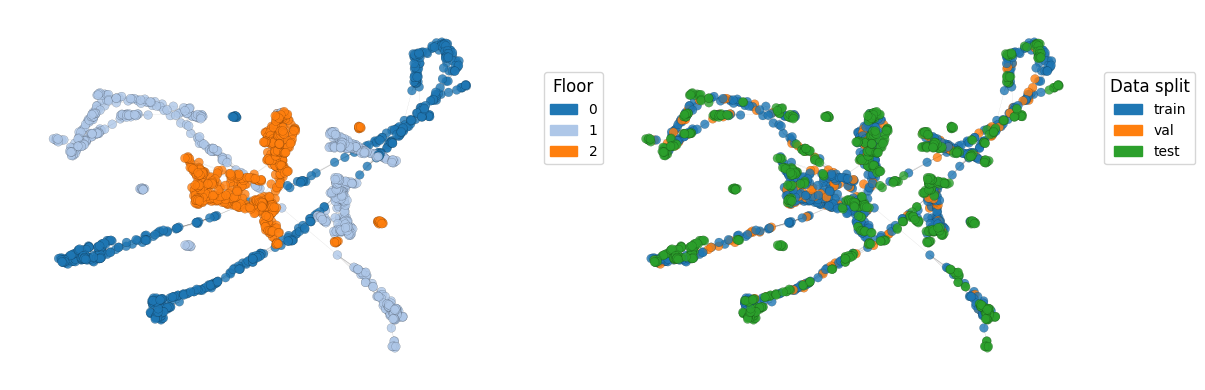

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) 

clusters = ['class', 'split']
graph_data = graph_datas['SOD01'][3]['transductive'].cls

for ax, cluster in zip(axes, clusters):
    gviz.draw_graph(graph_data, scheme="transductive", cluster=cluster, ax=ax) 
    
plt.tight_layout()
plt.show()

**Inductive scheme**

In [170]:
gdata = graph_datas["TUT1"][0]['splits'][0].cls
gdata

{'train': Data(num_nodes=1180, x=[1180, 55], num_features=55, edge_index=[2, 1768], k=1, y=[1180], num_classes=4),
 'val': Data(num_nodes=296, x=[296, 55], num_features=55, edge_index=[2, 428], k=1, y=[296], num_classes=4),
 'test': Data(num_nodes=490, x=[490, 55], num_features=55, edge_index=[2, 730], k=1, y=[490], num_classes=4)}

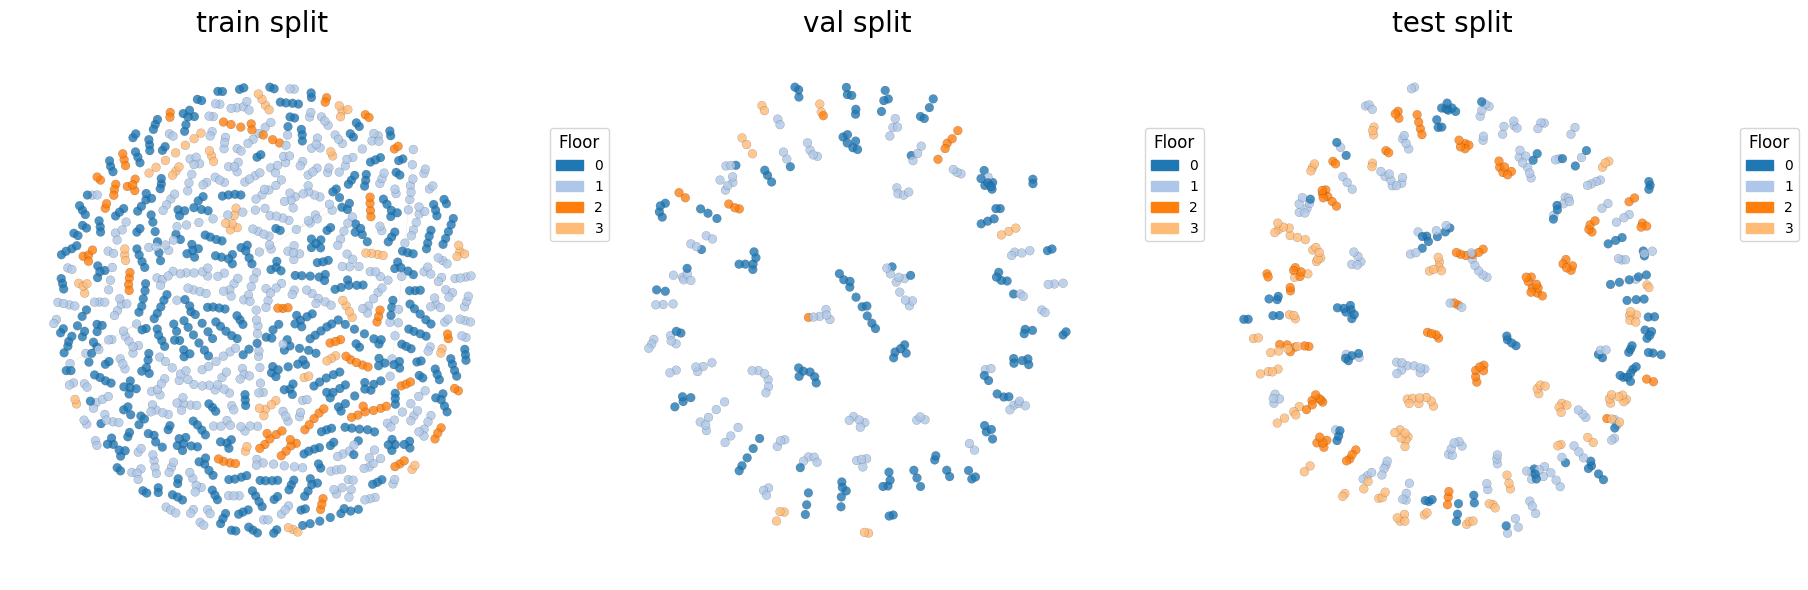

In [171]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6)) 

splits = ['train', 'val', 'test']

for ax, split in zip(axes, splits):
    gviz.draw_graph(gdata[split], scheme="inductive", cluster="class", ax=ax) 
    ax.set_title(f"{split} split", fontsize=20)

plt.tight_layout()
plt.show()

# 3. Training & Testing

## Regression

### Training

In [217]:
# Select dataset
dataset = "TIE1"
# Select graph
n_graph = 0
# Select data splits
graph_data = graph_datas[dataset][n_graph]['splits']
# Select models parameters
model_params = {
    'input_dim':graph_data[0].reg['train'].num_features if scheme == "inductive" \
                else graph_data.reg.num_features,
    'hidden_dim': [256, 256],
    'output_dim': 2, 
    'n_layers': 2,
    'dropout': [0.6],
    'learning_rate': 1e-2,
    'optim_factor': 0.9,
    'weight_decay': 1e-4,
    'mlp_layers': 4
}

for split in tqdm(range(len(graph_data)), desc="Training model"):
    model = SAGERegressor(**model_params).to("cuda")
    trainer = GNNRegressionTrainer().train_validate(
        data=graph_data[split].reg, 
        model=model,
        verbose=2,
        max_epochs=800,
        patience=200,
        show_train_process=False
    )
    model_path = os.path.join("../models", f"{learning_scheme}_{dataset}_g{n_graph}_s{split}.pt")
    torch.save(model.state_dict(), model_path)

Training model:   0%|          | 0/10 [00:00<?, ?it/s]

### Testing (Inference)

In [218]:
predictions = []
for split in tqdm(range(len(graph_data)), desc="Testing model"):
    prediction = GNNRegressionTrainer().test(
        data=graph_data[split].reg, 
        model=SAGERegressor(**model_params),
        pretrained_model=f"../models/{learning_scheme}_{dataset}_g{n_graph}_s{split}.pt"   
    )
    
    predictions.append(prediction)

Testing model:   0%|          | 0/10 [00:00<?, ?it/s]

#### Results

In [219]:
iltrainer.summarize_predictions(predictions=predictions, 
                               graph_params=graph_datas[dataset][n_graph]['parameters'], 
                               model_params=model_params,
                               save_path=f"../results/{learning_scheme}_{dataset}.csv")

,timestamp,mpe_mean,mpe_std,mae_mean,mae_std,mae_x_mean,mae_x_std,mae_y_mean,mae_y_std,elapsed_time_mean,elapsed_time_std
0,2026-02-15 13:50:08,5.1602,1.3941,3.1825,0.8532,4.3721,1.3774,1.993,0.6868,0.0121,0.0001
